# Controlled joint explosive-density and rock-density comparison

This notebook evaluates seven reconstructed burden equations at every
pair on two preselected density grids. It regenerates three CSV tables
and a three-panel figure for reproducible research comparison.

**Decision gate: `RESEARCH_COMPARATOR_ONLY`.** The sampled results
describe deterministic equation responses and structural disagreement.
They do not supply a validated field burden recommendation.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import numpy as np
import pandas as pd

from blastdesign import (
    build_gole_gohar_joint_density_sensitivity_table,
    build_joint_density_ensemble_summary,
    build_model_joint_density_response_summary,
    gole_gohar_reference_inputs,
)

start_directory = Path.cwd().resolve()
project_candidates = (start_directory, *start_directory.parents)
PROJECT_ROOT = next(
    (
        directory
        for directory in project_candidates
        if (directory / "pyproject.toml").is_file()
        and (directory / "src" / "blastdesign").is_dir()
    ),
    None,
)
if PROJECT_ROOT is None:
    raise RuntimeError(
        "Open this notebook from the BlastDesign-AI project "
        "or its notebooks directory."
    )

DATA_DIRECTORY = PROJECT_ROOT / "data" / "processed"
FIGURE_DIRECTORY = PROJECT_ROOT / "outputs" / "figures"
DATA_DIRECTORY.mkdir(parents=True, exist_ok=True)
FIGURE_DIRECTORY.mkdir(parents=True, exist_ok=True)

E = "explosive_density_g_cm3"
R = "rock_density_g_cm3"
RATIO = "explosive_to_rock_density_ratio"
reference_inputs = gole_gohar_reference_inputs()

print("Python executable:", sys.executable)
print("Project directory:", PROJECT_ROOT)

Python executable: C:\Users\A.Mehregan\miniconda3\envs\mining-ai\python.exe
Project directory: C:\Users\A.Mehregan\Projects\BlastDesign-AI


## Method

The default Cartesian grid combines seven explosive densities from
0.70 to 1.00 g/cm³ and twelve rock densities from 1.80 to 5.30 g/cm³.
Each of the 84 pairs is evaluated with all seven models, giving
588 model-output rows. Rock-density sampling includes 2.75 g/cm³
and the reconstructed reference value of 4.37 g/cm³.

Hole diameter (251 mm), UCS (85 MPa), the ANFO label, and Ash burden
ratio (25) remain fixed. The reference density pair is
0.85 g/cm³ explosive and 4.37 g/cm³ rock.

For the current reconstructed equations, define
$q = \rho_e / \rho_r$ and $d$ as hole diameter in metres:

$$B_{1972} = 37.8\,d\,q^{0.33}$$

$$B_{1983} = 12\,d\,(2q + 1.5).$$

The exponent **0.33** preserves the implemented reconstruction.
Only the two Konya equations respond to these density inputs.
Equal density ratios therefore give equal outputs at fixed diameter,
even when the individual density values differ.

The grids are exploratory computational settings. They do not define
equally probable rock types, validated geological domains, or an
operational range. Mineral, grain, dry-bulk, saturated-bulk, and in-situ
densities must not be treated as interchangeable. The fixed ANFO label
does not establish that every sampled explosive density describes
a realizable product with unchanged energy or performance.

In [2]:
model_outputs = build_gole_gohar_joint_density_sensitivity_table()
ensemble_summary = build_joint_density_ensemble_summary(model_outputs)
model_response_summary = build_model_joint_density_response_summary(
    model_outputs
)

print("Model outputs:", model_outputs.shape)
print("Ensemble summary:", ensemble_summary.shape)
print("Model response summary:", model_response_summary.shape)
print("Grid shape:", model_outputs.attrs["grid_shape"])
print("Density pairs:", model_outputs.attrs["scenario_count"])
print("Fixed inputs:", model_outputs.attrs["fixed_inputs"])
print("Decision gate:", model_outputs.attrs["decision_gate"])
print()
print(ensemble_summary.head().to_string(index=False))

Model outputs: (588, 6)
Ensemble summary: (84, 9)
Model response summary: (7, 17)
Grid shape: (7, 12)
Density pairs: 84
Fixed inputs: {'hole_diameter_mm': 251.0, 'ucs_mpa': 85.0, 'explosive_type': 'ANFO', 'ash_burden_ratio': 25.0}
Decision gate: RESEARCH_COMPARATOR_ONLY

 explosive_density_g_cm3  rock_density_g_cm3  explosive_to_rock_density_ratio  model_count  mean_burden_m  median_burden_m  minimum_burden_m  maximum_burden_m  range_m
                     0.7                1.80                         0.388889            7       6.507485         6.860667             5.773          6.983189 1.210189
                     0.7                2.10                         0.333333            7       6.410452         6.526000             5.773          6.983189 1.210189
                     0.7                2.40                         0.291667            7       6.333934         6.275000             5.773          6.983189 1.210189
                     0.7                2.60            

In [3]:
artifacts = (
    ("joint_density_sensitivity_model_outputs.csv", model_outputs),
    ("joint_density_sensitivity_ensemble_summary.csv", ensemble_summary),
    (
        "joint_density_sensitivity_model_response_summary.csv",
        model_response_summary,
    ),
)
for filename, table in artifacts:
    path = DATA_DIRECTORY / filename
    table.to_csv(
        path, index=False, encoding="utf-8", lineterminator="\n"
    )
    print("Saved:", path)

Saved: C:\Users\A.Mehregan\Projects\BlastDesign-AI\data\processed\joint_density_sensitivity_model_outputs.csv
Saved: C:\Users\A.Mehregan\Projects\BlastDesign-AI\data\processed\joint_density_sensitivity_ensemble_summary.csv
Saved: C:\Users\A.Mehregan\Projects\BlastDesign-AI\data\processed\joint_density_sensitivity_model_response_summary.csv


## Sampled density surfaces

The first two panels share a burden colour scale; the third has its
own range scale. Colour cells represent nearest sampled values on
the actual density coordinates. Uneven spacing on the rock-density
grid is retained, and the axes are clipped to the sampled interval.
Cell colours do not imply continuous field measurements.

Stars mark the reference pair. The dashed line is calculated directly
from $\rho_e = q_{ref}\rho_r$: all its points have the reference
density ratio. Under the implemented equations, both Konya burdens
and the seven-model range are constant along that line.

Saved figure: C:\Users\A.Mehregan\Projects\BlastDesign-AI\outputs\figures\joint_density_sensitivity_comparison.png


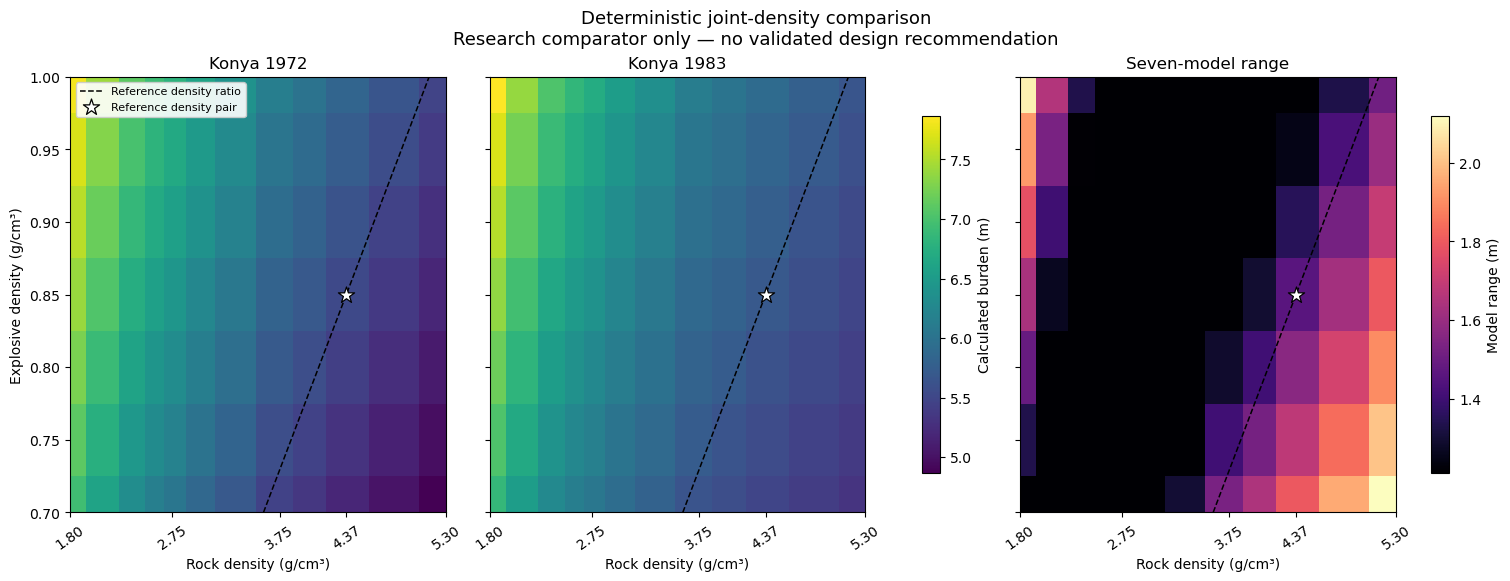

In [4]:
explosive_values = np.sort(model_outputs[E].unique())
rock_values = np.sort(model_outputs[R].unique())
konya_ids = ("CONV_KONYA_1972", "CONV_KONYA_1983")
surfaces = [
    model_outputs.loc[model_outputs["model_id"].eq(model_id)]
    .pivot(index=E, columns=R, values="burden_m")
    .reindex(index=explosive_values, columns=rock_values)
    .to_numpy()
    for model_id in konya_ids
]
range_surface = (
    ensemble_summary.pivot(index=E, columns=R, values="range_m")
    .reindex(index=explosive_values, columns=rock_values)
    .to_numpy()
)
burden_norm = Normalize(
    vmin=min(surface.min() for surface in surfaces),
    vmax=max(surface.max() for surface in surfaces),
)

fig, axes = plt.subplots(
    1, 3, figsize=(15, 5.7), sharey=True, constrained_layout=True
)
meshes = []
for axis, surface, title in zip(
    axes[:2], surfaces, ("Konya 1972", "Konya 1983")
):
    mesh = axis.pcolormesh(
        rock_values, explosive_values, surface,
        shading="nearest", cmap="viridis", norm=burden_norm,
    )
    meshes.append(mesh)
    axis.set_title(title)
range_mesh = axes[2].pcolormesh(
    rock_values, explosive_values, range_surface,
    shading="nearest", cmap="magma",
)
axes[2].set_title("Seven-model range")
fig.colorbar(
    meshes[0], ax=list(axes[:2]), shrink=0.82,
    label="Calculated burden (m)",
)
fig.colorbar(
    range_mesh, ax=axes[2], shrink=0.82, label="Model range (m)"
)

reference_ratio = reference_inputs[E] / reference_inputs[R]
line_minimum = max(rock_values.min(), explosive_values.min() / reference_ratio)
line_maximum = min(rock_values.max(), explosive_values.max() / reference_ratio)
line_rock = np.linspace(line_minimum, line_maximum, 200)
for axis in axes:
    axis.plot(
        line_rock, reference_ratio * line_rock,
        color="black", linestyle="--", linewidth=1.1,
        label="Reference density ratio",
    )
    axis.scatter(
        reference_inputs[R], reference_inputs[E],
        marker="*", s=150, color="white", edgecolors="black",
        linewidths=0.9, zorder=5, label="Reference density pair",
    )
    axis.set_xlim(rock_values.min(), rock_values.max())
    axis.set_ylim(explosive_values.min(), explosive_values.max())
    axis.set_xlabel("Rock density (g/cm³)")
    axis.set_xticks([1.8, 2.75, 3.75, 4.37, 5.3])
    axis.tick_params(axis="x", labelrotation=35)
axes[0].set_ylabel("Explosive density (g/cm³)")
axes[0].set_yticks(explosive_values)
axes[0].legend(loc="upper left", fontsize=8, framealpha=0.9)
fig.suptitle(
    "Deterministic joint-density comparison\n"
    "Research comparator only — no validated design recommendation",
    fontsize=13,
)

figure_path = FIGURE_DIRECTORY / "joint_density_sensitivity_comparison.png"
fig.savefig(figure_path, dpi=300, bbox_inches="tight", facecolor="white")
print("Saved figure:", figure_path)
plt.show()

In [5]:
reference_row = ensemble_summary.loc[
    ensemble_summary[E].eq(reference_inputs[E])
    & ensemble_summary[R].eq(reference_inputs[R])
].iloc[0]
minimum_range = ensemble_summary["range_m"].min()
maximum_range = ensemble_summary["range_m"].max()
minimum_rows = ensemble_summary.loc[
    np.isclose(
        ensemble_summary["range_m"], minimum_range,
        rtol=1e-12, atol=1e-12,
    )
]
maximum_rows = ensemble_summary.loc[
    np.isclose(
        ensemble_summary["range_m"], maximum_range,
        rtol=1e-12, atol=1e-12,
    )
]

print(f"Reference mean burden: {reference_row['mean_burden_m']:.6f} m")
print(f"Reference seven-model range: {reference_row['range_m']:.6f} m")
print(f"Minimum sampled seven-model range: {minimum_range:.6f} m")
print(f"Number of sampled minimum-range pairs: {len(minimum_rows)}")
print(f"Maximum sampled seven-model range: {maximum_range:.6f} m")
print(f"Reference density ratio: {reference_ratio:.6f}")
print("\nAll sampled pairs attaining the maximum range:")
print(maximum_rows[[E, R, RATIO, "range_m"]].to_string(index=False))
print("\nAll sampled pairs on the minimum-range plateau:")
print(minimum_rows[[E, R, RATIO]].to_string(index=False))
print("\nResponding models:")
print(
    model_response_summary.loc[
        model_response_summary["responds_to_joint_density_grid"],
        [
            "model_id", "reference_burden_m",
            "burden_at_minimum_density_ratio_m",
            "burden_at_maximum_density_ratio_m",
            "ratio_endpoint_change_m", "ratio_endpoint_change_percent",
        ],
    ].to_string(index=False)
)

Reference mean burden: 6.137371 m
Reference seven-model range: 1.455865 m
Minimum sampled seven-model range: 1.210189 m
Number of sampled minimum-range pairs: 44
Maximum sampled seven-model range: 2.118704 m
Reference density ratio: 0.194508

All sampled pairs attaining the maximum range:
 explosive_density_g_cm3  rock_density_g_cm3  explosive_to_rock_density_ratio  range_m
                     0.7                 5.3                         0.132075 2.118704

All sampled pairs on the minimum-range plateau:
 explosive_density_g_cm3  rock_density_g_cm3  explosive_to_rock_density_ratio
                    0.70                1.80                         0.388889
                    0.70                2.10                         0.333333
                    0.70                2.40                         0.291667
                    0.70                2.60                         0.269231
                    0.70                2.75                         0.254545
                   

In [6]:
# Demonstrate equal-ratio outputs at two different density pairs.
proportional_table = build_gole_gohar_joint_density_sensitivity_table(
    explosive_densities_g_cm3=[0.75, 0.90],
    rock_densities_g_cm3=[3.0, 3.6],
)
first = proportional_table.loc[
    proportional_table[E].eq(0.75) & proportional_table[R].eq(3.0)
].sort_values("model_id").reset_index(drop=True)
second = proportional_table.loc[
    proportional_table[E].eq(0.90) & proportional_table[R].eq(3.6)
].sort_values("model_id").reset_index(drop=True)
np.testing.assert_allclose(
    first["burden_m"], second["burden_m"], rtol=1e-12, atol=1e-12
)
print("Equal-ratio check PASSED: 0.75 / 3.0 = 0.90 / 3.6 = 0.25")
print("All seven model outputs agree for these two pairs.")

Equal-ratio check PASSED: 0.75 / 3.0 = 0.90 / 3.6 = 0.25
All seven model outputs agree for these two pairs.


## Interpretation

Only Konya 1972 and Konya 1983 change across the joint density grid.
Increasing explosive density at fixed rock density increases their
calculated burdens; increasing rock density at fixed explosive density
decreases them. Changing both densities proportionally preserves
their ratio and hence their calculated burdens.

The response-summary endpoint change is the burden at the **maximum
sampled density ratio minus the burden at the minimum sampled ratio**.
Its percentage uses the burden at the minimum ratio as its baseline.
This differs from the negative endpoint change in a rock-density-only
sweep, where explosive density remains fixed.

Multiple sampled pairs attain the minimum seven-model range. That
plateau describes which equations define the ensemble extremes; it
does not identify an optimal explosive, rock condition, or blast design.
The maximum range is an extremum of this preselected computational grid.

The range remains structural disagreement among reconstructed equations.
It is not a confidence interval, a calibrated prediction interval, or
evidence of predictive accuracy. The density-ratio dependence also
does not establish two independent physical mechanisms in blasting.

## Reproducible files

- Source: `src/blastdesign/joint_density.py`
- CSV export script: `scripts/generate_joint_density_artifacts.py`
- This notebook: `notebooks/joint_density_sensitivity_comparison.ipynb`
- Figure: `outputs/figures/joint_density_sensitivity_comparison.png`
- Model outputs: `data/processed/joint_density_sensitivity_model_outputs.csv`
- Ensemble summary: `data/processed/joint_density_sensitivity_ensemble_summary.csv`
- Model responses: `data/processed/joint_density_sensitivity_model_response_summary.csv`
- Tests: `tests/test_joint_density.py`, `tests/test_joint_density_summary.py`,
  and `tests/test_joint_density_artifacts.py`

Run all notebook cells in order using the project environment. The
notebook and export script use the same default builders and CSV
formatting. Saved-artifact tests compare the CSV contents with fresh
calculations. DataFrame attributes are not serialized into CSV;
interpretation and measurement-basis warnings are recorded here
and in the source module.